# Tarea N.2 Graficacion en en Python 
**Arenas Limon Angel Daniel**

## 1. Grafica de datos experimentales

**a)** Escribe un programa que lea los datos y haga una grafica de las manchas  solares en funcion del tiempo.  

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
Arch = "manchasolares.txt" #el documento jupyter debe de estar en la misma carpeta en donde esta el archivo, :)

In [6]:
meses = []
manchas_solares = []

with open(Arch, "r") as f:
    for linea in f:
        datos = linea.strip().split()
        if len(datos) == 2:  
            meses.append(int(datos[0]))  
            manchas_solares.append(float(datos[1]))  

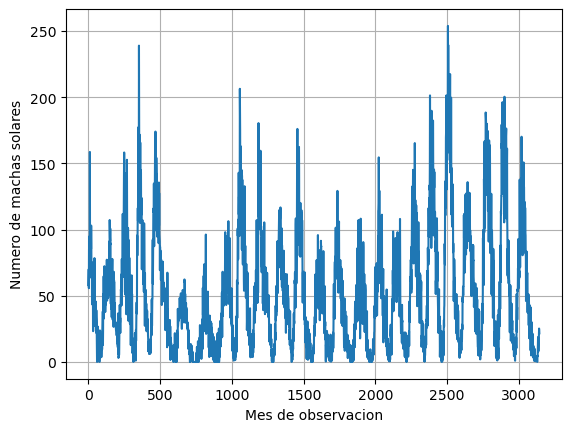

In [8]:
plt.plot(meses, manchas_solares)
plt.xlabel("Mes de observacion")
plt.ylabel("Numero de machas solares")
plt.grid()

**b)** Modifica tu programa para mostrar solo los primeros 1000 datos (experimentales)
en la grafica. 

In [10]:
meses_reducidos = []
manchas_solares_reducidas = []
with open(Arch, "r") as f:
    for i,linea in enumerate(f):
        if i>= 1000:
            break
        datos = linea.strip().split()
        if len(datos) == 2:  
            meses_reducidos.append(int(datos[0]))  
            manchas_solares_reducidas.append(float(datos[1]))  

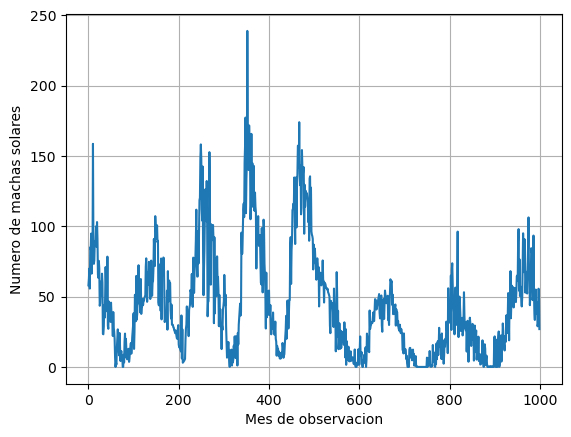

In [12]:
plt.plot(meses_reducidos, manchas_solares_reducidas)
plt.xlabel("Mes de observacion")
plt.ylabel("Numero de machas solares")
plt.grid()

**c)** Modifica nuevamente tu programa para calcular y graficar la media (promedio)
movil de los datos, definida por:

$$\displaystyle{Y_k = \frac{1}{2r + 1}\sum\limits^r_{m=-r}Y_{k+m}}$$

In [12]:
r = 5
media_movil = []
for m in range(len(manchas_solares_reducidas)):
    inicio = max(0, m - r)  
    fin = min(len(manchas_solares_reducidas), m + r + 1)  
    promedio = np.mean(manchas_solares_reducidas[inicio:fin])  
    media_movil.append(promedio)

In [14]:
min?

Docstring:
min(iterable, *[, default=obj, key=func]) -> value
min(arg1, arg2, *args, *[, key=func]) -> value

With a single iterable argument, return its smallest item. The
default keyword-only argument specifies an object to return if
the provided iterable is empty.
With two or more arguments, return the smallest argument.
Type:      builtin_function_or_method

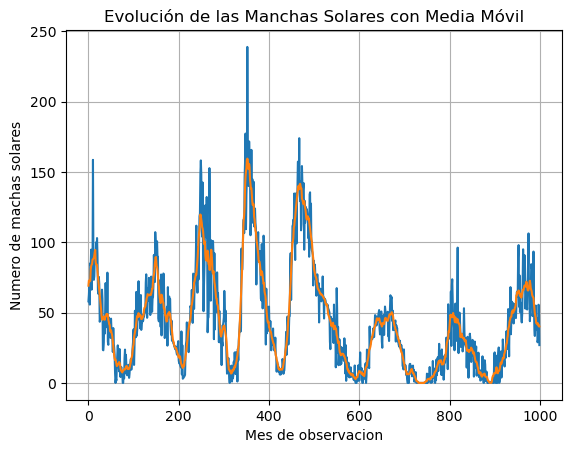

In [16]:
plt.plot(meses_reducidos, manchas_solares_reducidas)
plt.plot(meses_reducidos, media_movil)
plt.xlabel("Mes de observacion")
plt.ylabel("Numero de machas solares")
plt.title("Evolución de las Manchas Solares con Media Móvil")
plt.grid()

## 2. Grafica de curvas

Aunque la funcion.plot esta diseñada principalmente para hacer graficos xy estandar,  ́
se puede adaptar para otros tipos de graficas tambien  ́

**a)** Grafica la llamada curva deltoide, definida parametricamente por las ecuaciones:
\begin{align}
    x=2cos(\theta) + cos(2\theta)\\
    y=2 sen\theta − sen 2\theta
\end{align}
donde 0 $\leq$ θ $<$ $2\pi$. Toma un conjunto de valores para $\theta$ entre 0 y $2\pi$ y calcula
$x(\theta)$ e $y(\theta)$ usando las ecuaciones anteriores, para posteriormente graficar y como
funcion de  $x$.

In [30]:
theta = np.linspace(0, 2*np.pi,500)

x = 2*np.cos(theta) + np.cos(2*theta)
y = 2*np.sin(theta) - np.sin(2*theta)

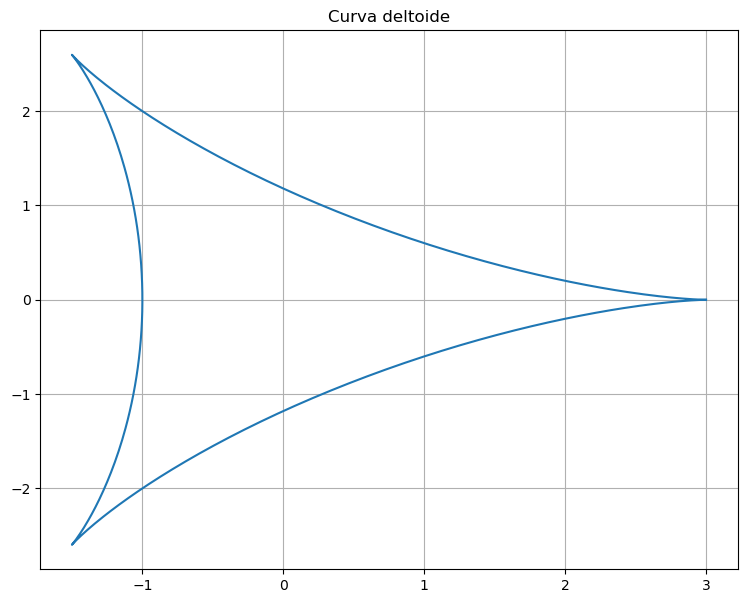

In [32]:
plt.figure(figsize=(9, 7))
plt.plot(x, y)
plt.title("Curva deltoide")
plt.grid()

**(b)** Usando este mismo enfoque, se puede hacer una gráfica polar $ r = f(\theta)$ para alguna función $f$ calculando $r$ para un rango de valores de $\theta$ y luego convirtiendo $r$ y $\theta$ a coordenadas cartesianas usando las ecuaciones estándar:

$$
x = r \cos \theta, \quad y = r \sin \theta
$$

Utiliza este método para trazar la *espiral Galileana* $r = \theta^2$ para $0 \leq \theta \leq 10\pi $.

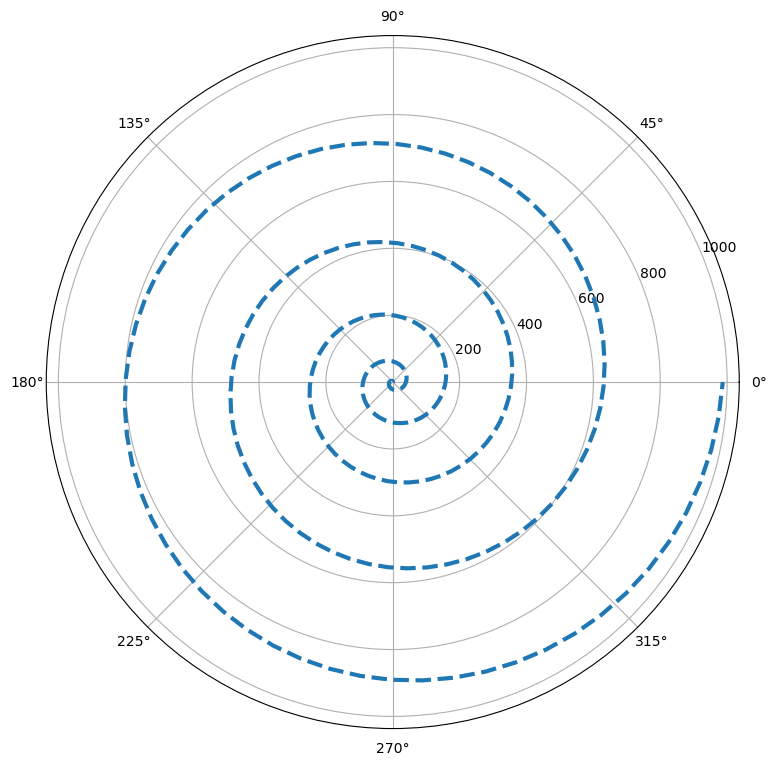

In [22]:
theta = np.linspace(0,10*np.pi, 300) 
r = theta*theta 

fig = plt.figure(figsize=(15,9)) 
plt.polar(theta,r,linewidth=3, linestyle="--")  

**(c)** Con el mismo método, haz una gráfica polar de la "función de Fey":

$$
r = e^{\cos \theta} - 2\cos 4\theta + \sin^5 \frac{\theta}{12}
$$

en el rango $0 \leq \theta \leq 24\pi$.


In [36]:
tetha_2 = np.linspace(0,24*np.pi, 3000) 
r = (np.exp(np.cos(tetha_2))) - (2*np.cos(4*tetha_2) )+ np.sin(tetha_2/12)**5 

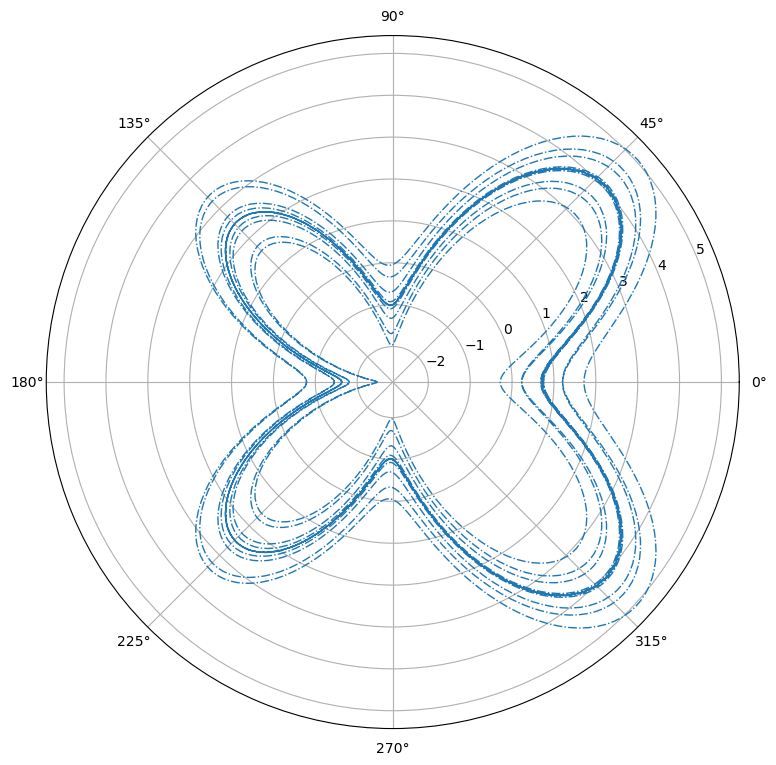

In [38]:
fig = plt.figure(figsize=(15,9)) 
plt.polar(tetha_2,r,linewidth=1, linestyle="-.")

## 3. La grfica de Feigenbaum (caos determinista)

En un especial halloween de los Simpsons, Homero viaja al pasado a la era Jurasica y por un pequeno descuido cambia el curso de toda la historia en el futuro. Lo anterior es una referencia al cuento A Sound of Thunder de 1952 del escritor de ciencia ficcion ́Ray Bradbury en donde lo que se destruye en el pasado es una mariposa. Esta idea fue retomada y popularizada por el f ́ısico Edward Lorenz en 1972 cuando dio una conferencia en la Asociacion Estadounidense para el Avance de la Ciencia ($American$ $Association$ $for$ $the$ $Advancement$ $of$ $cience$) titulada “¿El aleteo de una mariposa en Brasil puede provocar un tornado en Texas?. Dando paso al concepto del efecto mariposa, del
cual probablemente hayas o ́ıdo hablar y que es el ejemplo clasico de caos determinista en sistemas climaticos. El caos determinista tambien aparece en muchos sistemas fısicos mas complejos, incluyendo especialmente la dinamica de fluidos. Debido a su naturaleza aparentemente aleatoria, el comportamiento de los sistemas caoticos es difıcil de predecir y se ve fuertemente afectado por pequenas perturbaciones en las condiciones iniciales. Uno de los ejemplos mas famosos del fenomeno del caos determinista es sin duda el mapeo logıstico, que es un sistema matematico muy simple, definido por la ecuacion:

\begin{align}
    x_{n+1} = rx_n(1 - x_n)
\end{align}

Para un valor dado de la constante $r$, se toma un valor de $x_n$ (digamos $x = 1/2$) y se introduce en el lado derecho de esta ecuacion y regresa un valor de  $x_{n+1}$. Luego se toma ese valor y se vuelve a introducir en el lado derecho, lo que da otro valor, y ası sucesivamente. Esto es un mapeo iterativo. Se continua haciendo la misma operacion una y otra vez sobre su valor de xn, y entonces sucede una de las tres siguiente situaciones:

**(i)** El valor se establece en un numero fijo y permanece allı. Esto se llama punto fijo. Por ejemplo, $x_n = 0$ es siempre un   punto fijo del mapeo logıstico. (Si se pone $x_n = 0$ en el lado derecho se obtiene $x_{n+1} = 0$ en el lado izquierdo). 

**(ii)** No se establece en un solo valor, sino que se establece en un patron periodico, rotando alrededor de un conjunto de valores, digamos cuatro valores, repitiendose en secuencia una y otra vez. Esto se llama orbita (en este caso de periodo 4) o ciclo lımite. 

**(iii)** Todo enloquece. El mapeo, genera una secuencia aparentemente aleatoria de numeros que parecen no tener ni patron ni razon (ni ton ni son). Esto es el caos determinista. “Caos” porque realmente parece caotico y “determinista” porque aunque los valores parecen aleatorios, no lo son. Son a todas luces, totalmente predecibles, porque se obtienen mediante una simple ecuacion y el comportamiento esta ́ determinado, aunque no lo parezca.


**a)** Apoyate en el programa que vimos en clase y escribe un programa que muestre el comportamiento del mapeo logıstico mediante una grafica.  ́

In [20]:
def Logistico(r,x):
    return r*x*(1-x) # Esta es la funcion que definimos en clase
    
r1 = np.linspace(2.5, 4.0, 10000)    
r2 = np.arange(1,4,0.01) #El rango sobre el que correr r

<>:17: SyntaxWarning: invalid escape sequence '\i'
<>:17: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_13519/2810710181.py:17: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel("$x_{\infty}$")


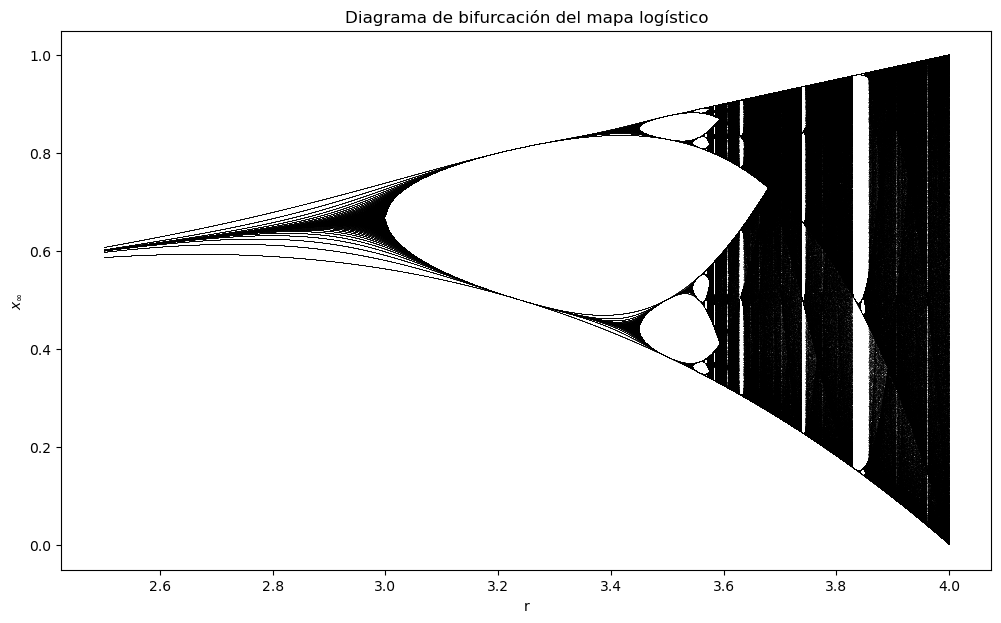

In [19]:
plt.figure(figsize=(12, 7))

for r in r1:
    x = 0.5  # Condición inicial
    x = Logistico(r, x)
    # Guardamos los puntos del atractor
    xs = []
    for _ in range(1000):
        x = Logistico(r, x)
        xs.append(x)
    plt.plot([r]*1000, xs, ',k', alpha=0.25)



plt.title("Diagrama de bifurcación del mapa logístico")
plt.xlabel("r")
plt.ylabel("$x_{\infty}$")
plt.show()

**b)** De acuerdo a tu grafica, ¿a que valor de r el sistema pasa de un comportamiento ordenado (puntos fijos o ciclos lımite) a un comportamiento caotico? A este punto  a veces se le llama el borde del caos”.

El valor es sercano al **3.6**, pero no estoy del todo seguro que sea valor

**c)** Hay otra forma para calcular el diagrama de Feigenbaum, que puede ser mas claro y rapido, dado que hace uso de la capacidad de Python para realizar aritmetica con arreglos completos. Crear un arreglo  $r$ que contenga cada valor distinto de r, [1.0, 1.01, 1.02, ... ]. Crea otro arreglo $x$ del mismo tamano para guardar los valores correspondientes de  $x$, establecidos inicialmente en 0,5; finalmente realiza una iteracion del mapeo logıstico para todos los valores de $r$ a la vez, con una sola instruccion de la forma  $x = rx(1-x)$ y comparala con tu programa anterior.

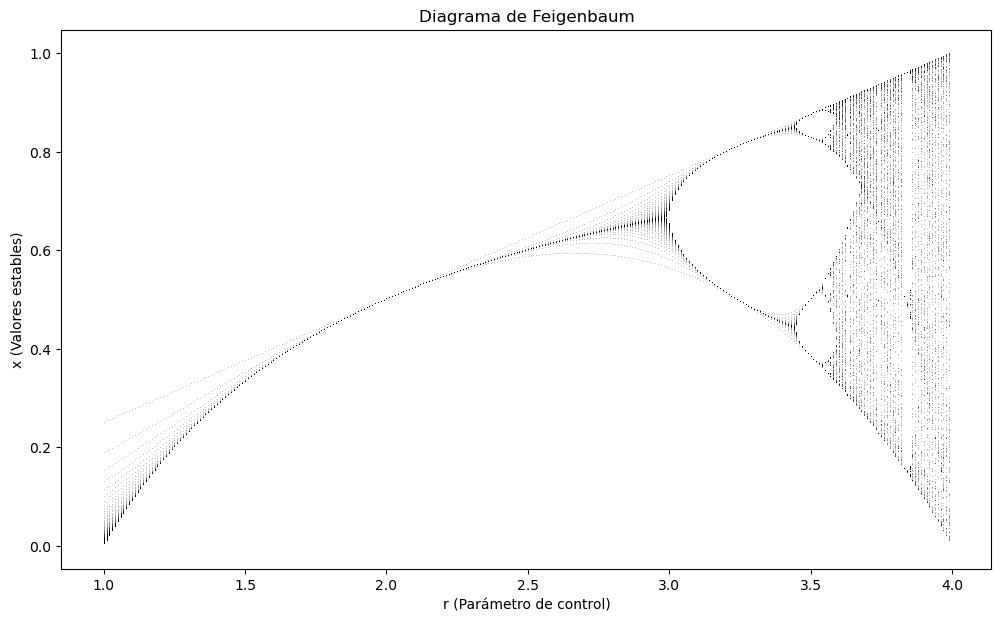

In [38]:
plt.figure(figsize=(12, 7))

Rs = np.arange(1,4,0.01) 
n = len(Rs)

Xs = np.ones_like(r_values) * 0.5

for r in Rs:
    Xs = Rs * Xs * (1 - Xs)
    # Graficar solo después del transitorio
    if _ >= n:
        plt.plot(Rs, Xs, ',k', alpha=0.25)

plt.title("Diagrama de Feigenbaum")
plt.xlabel("r (Parámetro de control)")
plt.ylabel("x (Valores estables)")
plt.show()

## 4. El conjunto de Mandelbrot

El conjunto de Mandelbrot, llamado ası por su descubridor, el matematico frances Benoıt Mandelbrot, es un fractal; un objeto matematico infinitamente ramificado que contiene estructura dentro de estructura dentro de estructura, tan profundamente como queramos mirar. La definicion del conjunto de Mandelbrot en terminos de numeros complejos es la siguiente. Consideremos la ecuacion:  ́

\begin{align}
    (z_{n+1} =z^2_n + c) \text{  $z_n,c \in \mathbb{C}$}
\end{align}

donde $z_n$ es un numero complejo y  $c$ es una constante compleja. De manera, muy
similar al mapeo logıstico, la definicion del conjunto de Mandelbrot implica la iteracion repetida de esta ecuacion para cualquier valor dado de  c. La ecuacion convierte un numero de entrada $z_n$ en un numero de salida  $z_{n+1}$; de tal manera que se toma un
valor inicial de $z_0$ y se introduce en la ecuacion para obtener un nuevo valor $z_1$, luego tomamos ese valor y lo volvemos a introducir para obtener $z_2$ y ası sucesivamente.

Ası, el conjunto de Mandelbrot es el conjunto de puntos del plano complejo que satisface la siguiente definicion:

**Para un valor dado de $c$ y la condicion inicial $z_0 = 0$; si al iterar repetidamente la
ecuaciin, la magnitud del valor resultante es mayor a dos (i.e. $|z^{\infty}| > 2$), entonces el punto del plano complejo para ese valor $c$ no esta en el conjunto de Mandelbrot; de lo contrario, si esta en el conjunto**

**a)**  Escribe un programa para crear una imagen del conjunto de Mandelbrot realizando la iteracion para todos los valores de  $c = x + iy$ en una cuadrıcula de $N × N$ que abarque la region donde  $(−2 ≤ x ≤ 2)$ y $(−2 ≤ y ≤ 2)$. Haz una grafica de densidad (density plot) en el que los puntos de la cuadricula dentro del conjunto de Mandelbrot esten coloreados en negro y los de afuera esten coloreados en blanco.

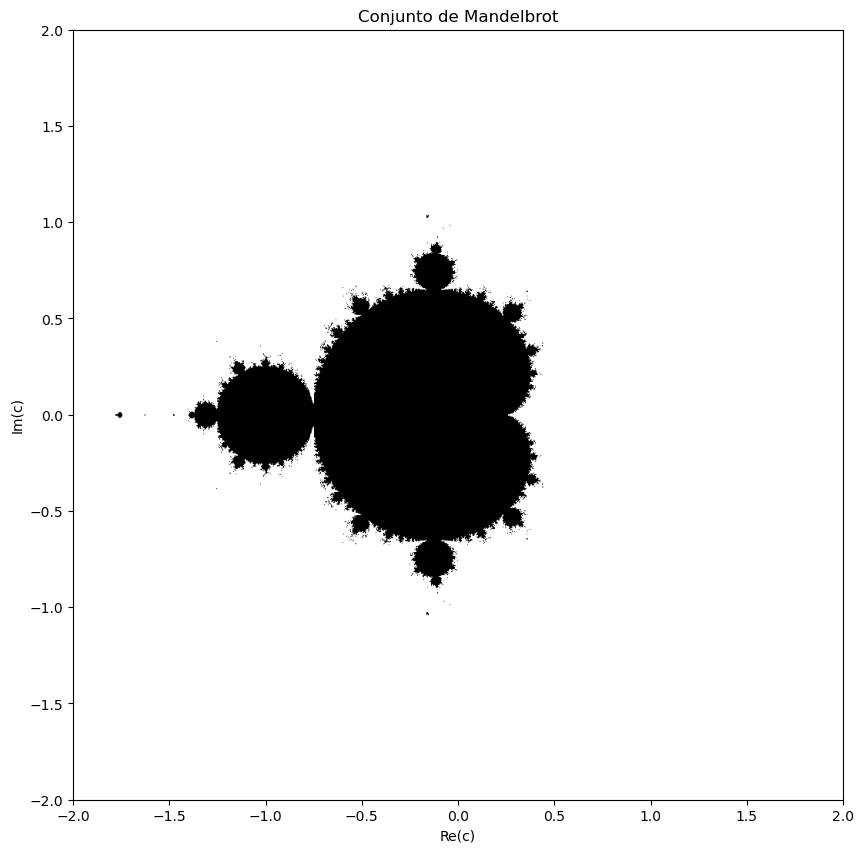

In [44]:
N = 1000  # Resolución (N x N)
x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0


x = np.linspace(x_min, x_max, N)
y = np.linspace(y_min, y_max, N)
X, Y = np.meshgrid(x, y)
C = X + 1j * Y  # Matriz de números complejos

mandelbrot = np.zeros((N, N), dtype=int) # Iniciamos la matriz de salida (1 = dentro del conjunto, 0 = fuera)

# Número máximo de iteraciones y criterio de divergencia
max_iter = 50
escape_radius = 2.0

# Iterar para cada punto c
for i in range(N):
    for j in range(N):
        z = 0
        c = C[i, j]
        for k in range(max_iter):
            z = z**2 + c
            if abs(z) > escape_radius:
                break
        else:
            mandelbrot[i, j] = 1  # Punto dentro del conjunto

# Graficar (negro = dentro, blanco = fuera)
plt.figure(figsize=(10, 10))
plt.imshow(mandelbrot, cmap='binary', extent=(x_min, x_max, y_min, y_max))
plt.title("Conjunto de Mandelbrot")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.show()


**b)** Si te aburrio lo anterior (o te resulto demasiado facil), puedes programar otra variante del mismo ejercicio que puede producir imagenes sorprendentes. En lugar de colorear los puntos solo en blanco o negro, colorea los puntos de acuerdo con el numero de iteraciones de la ecuacion antes de que $|zn|$ sea mayor que 2 (o bien el numero maximo de iteraciones si es que  ́$|zn|$ nunca llega a ser mayor que 2). Si usas alguno de los esquemas mas coloridos que Python proporciona para las graficas de densidad, como   "hot" or “jet”, puedes
crear algunas imagenes muy espectaculares. Otra variante interesante es colorear segun el logaritmo del numero de iteraciones, lo que ayuda a revelar parte de la estructura mas fina fuera del conjunto. 

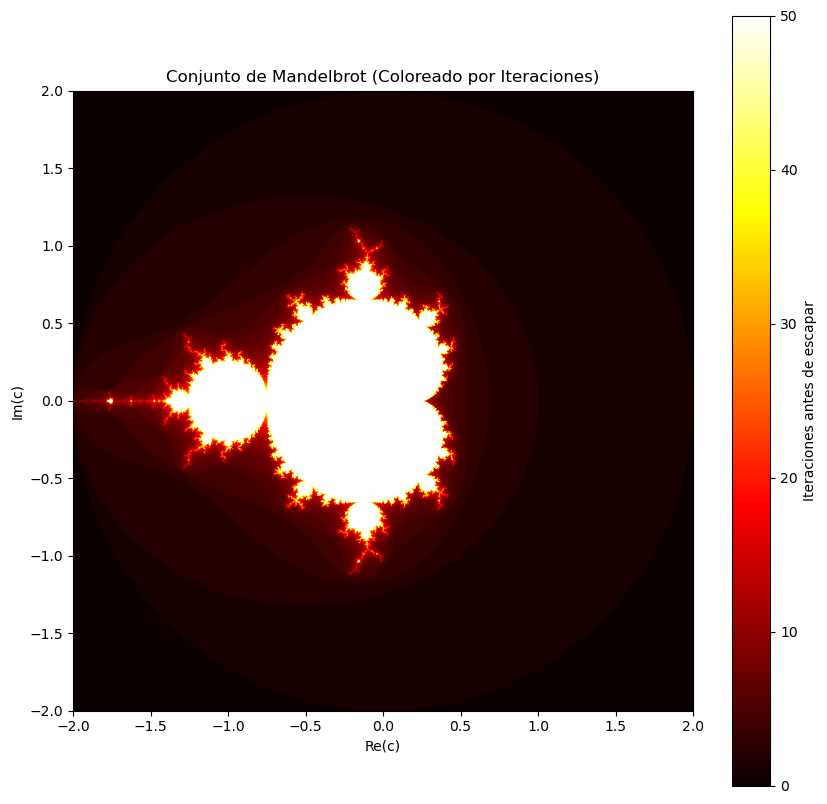

In [49]:
iteraciones = np.zeros((N, N), dtype=int)

for i in range(N):
    for j in range(N):
        z = 0j
        c = C[i, j]
        for k in range(max_iter):
            z = z**2 + c
            if abs(z) > escape_radius:
                iteraciones[i, j] = k  # Guardar el número de iteraciones
                break
        else:
            iteraciones[i, j] = max_iter  # Nunca escapó

plt.figure(figsize=(10, 10))
plt.imshow(iteraciones, cmap='hot', extent=(x_min, x_max, y_min, y_max))
plt.colorbar(label="Iteraciones antes de escapar")
plt.title("Conjunto de Mandelbrot (Coloreado por Iteraciones)")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.show()